# How to use torch-tk with a custom model
This notebook is a practical introduction to torch-tk.

The main idea behind **torch-tk** is that it adds a small amount of structure around ordinary torch models and optimizers so that they become easier to save, restore, reconstruct, and train. In particular, **torch-tk** provides a model base class, a checkpoint manager, a trainer, and diagnostics utilities.

**torch-tk** models can describe themselves. A model derived from `torch_tk.models.Model` provides the information needed to save its state and recreate the same model instance later. In practice, this means the model can expose its trainable parameters, return the constructor arguments needed to rebuild it, and load a saved state back into a fresh instance.

A second useful feature is the `CheckPointManager`. Rather than saving only raw parameter tensors, it saves enough information to reconstruct both the model and the optimizer in the state that created the checkpoint. This makes it easier to stop and resume training without manually rebuilding all objects.

**torch-tk** also includes a `Trainer` class for running epoch-based training. It supports training either from a `DataLoader` or directly from tensors, and it records simple diagnostics such as training loss and epoch wallclock time.

In addition, **torch-tk** provides a `Diagnostics` class for storing sample-resolved loss information together with training metadata. These diagnostics can be created from tensors or data loaders and can be saved to netCDF for later analysis.

In this notebook, we will build a minimal custom model class that works with these torch-tk components. The goal is not to introduce a complicated architecture, but to show clearly how such a model needs to be written so that it can be trained, checkpointed, restored, and analyzed within the torch-tk framework.

The notebook:

- creates a simple synthetic dataset for the example
- defines a custom model class that is compatible with torch-tk and creates a model instance
- creates an optimizer and specifies the loss function
- creates a trainer and a checkpoint manager
- initializes diagnostics
- runs a training loop and plots loss and wallclock time as functions of epoch
- saves the model, optimizer, and diagnostics to disk
- recreates the model, optimizer, and diagnostics from disk
- creates a new trainer and checkpoint manager
- resumes training from the restored state, and plots loss and wallclock time as functions of epoch
- again saves the model, optimizer, and diagnostics to disk
- finishes by plotting the model diagnostics: PDFs of per-sample loss for the training and validation datasets as functions of epoch

## Preliminaries

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import random
import numpy as np

import torch

from torch_tk.models import Model
from torch_tk.optimizers import Adam
from torch_tk.training import Trainer
from torch_tk.checkpoints import CheckPointManager
from torch_tk.diagnostics import Diagnostics, plot_diagnostics

### Set random seed

In [3]:
seed = 999

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

### Set device

In [4]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

## Create a dataset

Input values are 1000 vectors of 100 random numbers

In [5]:
sample_n = 1000
in_dim_n = 100
out_dim_n = 1

In [6]:
x_data = torch.randn(size=[sample_n,in_dim_n],dtype=torch.float32)

Target values are the maximum of each of the 1000 vectors

In [7]:
y_data = x_data.amax(dim=tuple(range(1, x_data.ndim))).unsqueeze(1)

## Create a custom model class

We create a simple model class that can be used with the torch-tk `CheckPointManager`.

At its core, this class is like any torch model: it defines a `forward` method for the model forward pass.

A model used with torch-tk must provide the following method so that it can later be saved and reconstructed automatically:

- `constructor_dict` returns the arguments needed to recreate the model instance.

Rather than building all of this from scratch, we inherit from the abstract base class `torch_tk.models.Model`. This class inherits from `torch.nn.Module`. We only need to implement the model-specific parts.

In [8]:
class MyModel(Model):
    
    def __init__(self,in_dim_n,out_dim_n,device=None):
        
        super().__init__()
        
        self.in_dim_n = in_dim_n
        self.out_dim_n = out_dim_n
        self.device = device
        
        self.fc1 = torch.nn.Linear(in_dim_n,in_dim_n,device=device)
        self.ac1 = torch.nn.ReLU()
        self.fc2 = torch.nn.Linear(in_dim_n,out_dim_n,device=device)

    def forward(self,xb):

        xb = self.fc1(xb)
        xb = self.ac1(xb)
        xb = self.fc2(xb)

        return xb

    def constructor_dict(self):
        '''
        Returns a dictionary with the model constructor arguments.
        '''
        return {
        'args' : (self.in_dim_n,self.out_dim_n),
        'kwargs' : {'device': self.device}
        }

## Create a model instance

In [9]:
model = MyModel(in_dim_n,out_dim_n,device=device)

In [10]:
model_name = type(model).__name__

## Create an optimizer

In [11]:
lr = 1E-5

In [12]:
optimizer = Adam(model.parameters(),lr=lr)

In [13]:
optimizer_name = type(optimizer).__name__

## Loss function

Sample-resolved loss function

In [14]:
def loss_function_sample_resolved(prediction, target):
    '''
    Compute the mean squared error for each prediction/target sample pair.
    '''
    error = prediction - target
    if error.ndim == 1:
        return error.pow(2).mean()
    return error.pow(2).mean(dim=tuple(range(1, error.ndim)))

Mean sample loss

In [15]:
def loss_function(prediction, target):
    '''
    Compute the mean of the sample-resolved loss.
    '''
    return loss_function_sample_resolved(prediction,target).mean()

## Create a trainer

In [16]:
trainer = Trainer(model,optimizer,loss_function)

## Create a checkpoint manager

In [17]:
checkpoint_dir = Path('checkpoints')

In [18]:
checkpoint_manager = CheckPointManager(model,optimizer,checkpoint_dir)

## Construct training and validation datasets

In [19]:
val_frac = 0.2
data_n = x_data.shape[0]
valid_n = int(0.2*data_n)
train_n = data_n - valid_n

Create a random permutation of the indices selecting model input

In [20]:
index_perm = torch.randperm(data_n)

Indices of the training and validation samples in the original dataset, if needed later

In [21]:
index_train = index_perm[0:train_n]
index_valid = index_perm[train_n:]

The training and validation datasets

In [22]:
train_data_description = 'Training data'
valid_data_description = 'Validation data'

In [23]:
x_train = x_data[index_train].to(device)
y_train = y_data[index_train].to(device)

x_valid = x_data[index_valid]
y_valid = y_data[index_valid]

## Training parameters

Batch size

In [24]:
bs = 20

Number of epoch cycles, number of epochs in each cycle, number of epochs before storing training diagnostics

In [25]:
epoch_cycles = 5
epochs = 100
training_diag_step = epochs

## Initialize diagnostics

In [26]:
diagnostics_dir = Path('diagnostics')

In [27]:
train_diagnostics = Diagnostics(model_name,optimizer_name,lr,bs,description=train_data_description)
valid_diagnostics = Diagnostics(model_name,optimizer_name,lr,bs,description=valid_data_description)

## Training loop

In [28]:
for cycle in range(epoch_cycles):
    # Training
    trainer.train_with_data(x_train,y_train,bs,epochs,epoch_diag_step=training_diag_step,x_valid=x_valid,y_valid=y_valid)
    # Calculate model diagnostics
    train_diagnostics += Diagnostics.from_data(model,loss_function_sample_resolved,optimizer,lr,bs,x_train,y_train,description=train_data_description,epoch=trainer.epoch,chunk_size=2**16)
    valid_diagnostics += Diagnostics.from_data(model,loss_function_sample_resolved,optimizer,lr,bs,x_valid,y_valid,description=valid_data_description,epoch=trainer.epoch,chunk_size=2**16)

Training epoch 100 wallclock time (s): 1.5582E-02, training loss : 1.591675, validation loss : 1.853556
Training epoch 200 wallclock time (s): 2.0284E-02, training loss : 0.256477, validation loss : 0.391800
Training epoch 300 wallclock time (s): 1.5380E-02, training loss : 0.131881, validation loss : 0.243211
Training epoch 400 wallclock time (s): 2.0467E-02, training loss : 0.090254, validation loss : 0.229738
Training epoch 500 wallclock time (s): 1.5620E-02, training loss : 0.061086, validation loss : 0.229412


### Save checkpoint

In [29]:
check_point_file = checkpoint_manager.save(trainer.epoch)

### Save diagnostics

In [30]:
train_diag_file = train_diagnostics.to_netcdf(diagnostics_dir)
valid_diag_file = valid_diagnostics.to_netcdf(diagnostics_dir)

Saved diagnostics in  diagnostics/MyModel.Adam.Training data.epoch=100_to_500.nc
Saved diagnostics in  diagnostics/MyModel.Adam.Validation data.epoch=100_to_500.nc


### Plot training diagnostics

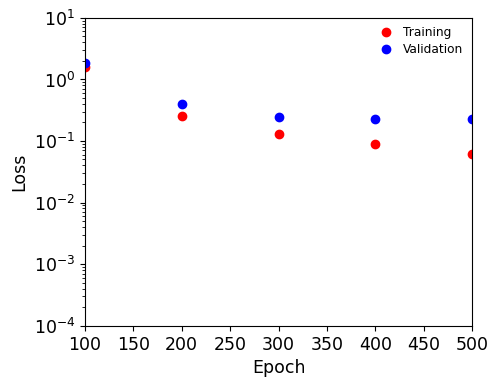

In [31]:
trainer.plot_loss(figsize=(5, 4),font_factor=1.25,ylog=True,ylim=[0.0001,10])

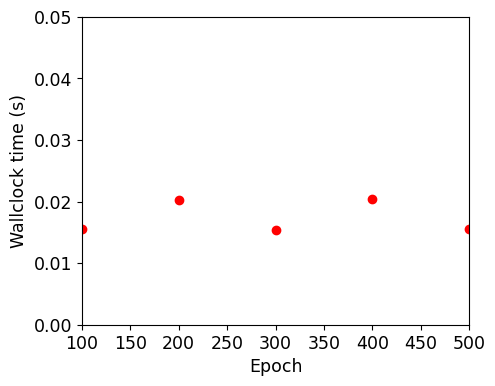

In [32]:
trainer.plot_wallclock_time(figsize=(5, 4),font_factor=1.25,ylim=[0,5e-2])

### Discard the existing model, optimizer, checkpoint manager, and diagnostics instances (we will recreate them from saved files)

In [33]:
model = None
optimizer = None
checkpoint_manager = None
train_diagnostics = None
valid_diagnostics = None

## Recreate the model, optimizer, and diagnostics from saved files

Load the saved checkpoint file and reconstruct the checkpoint manager, model, and optimizer

In [34]:
checkpoint_manager, model, optimizer, epoch = CheckPointManager.load_from_file(check_point_file)

Load the saved diagnostics file

In [35]:
train_diagnostics = Diagnostics.from_netcdf(train_diag_file)
valid_diagnostics = Diagnostics.from_netcdf(valid_diag_file)

## Create a trainer

Initialize the trainer with the last epoch from the previous training

In [36]:
trainer = Trainer(model,optimizer,loss_function,epoch=epoch)

## Training loop

In [37]:
for cycle in range(epoch_cycles):
    # Training
    trainer.train_with_data(x_train,y_train,bs,epochs,epoch_diag_step=training_diag_step,x_valid=x_valid,y_valid=y_valid)
    # Calculate model diagnostics
    train_diagnostics += Diagnostics.from_data(model,loss_function_sample_resolved,optimizer,lr,bs,x_train,y_train,description=train_data_description,epoch=trainer.epoch,chunk_size=2**16)
    valid_diagnostics += Diagnostics.from_data(model,loss_function_sample_resolved,optimizer,lr,bs,x_valid,y_valid,description=valid_data_description,epoch=trainer.epoch,chunk_size=2**16)

Training epoch 600 wallclock time (s): 1.6326E-02, training loss : 0.038200, validation loss : 0.232427
Training epoch 700 wallclock time (s): 1.5994E-02, training loss : 0.021078, validation loss : 0.236565
Training epoch 800 wallclock time (s): 1.6158E-02, training loss : 0.009593, validation loss : 0.240942
Training epoch 900 wallclock time (s): 1.6115E-02, training loss : 0.003106, validation loss : 0.245218
Training epoch 1000 wallclock time (s): 2.0373E-02, training loss : 0.000453, validation loss : 0.248719


### Save checkpoint

In [38]:
check_point_file = checkpoint_manager.save(trainer.epoch)

### Save diagnostics

In [39]:
train_diag_file = train_diagnostics.to_netcdf(diagnostics_dir)
valid_diag_file = valid_diagnostics.to_netcdf(diagnostics_dir)

Saved diagnostics in  diagnostics/MyModel.Adam.Training data.epoch=100_to_1000.nc
Saved diagnostics in  diagnostics/MyModel.Adam.Validation data.epoch=100_to_1000.nc


### Plot training diagnostics

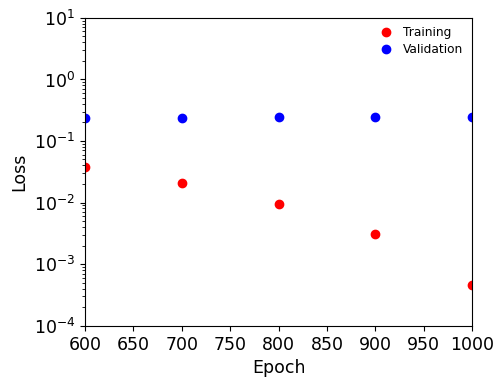

In [40]:
trainer.plot_loss(figsize=(5, 4),font_factor=1.25,ylog=True,ylim=[0.0001,10])

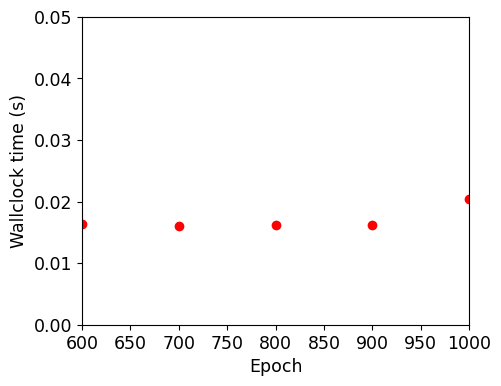

In [41]:
trainer.plot_wallclock_time(figsize=(5, 4),font_factor=1.25,ylim=[0,5e-2])

## Plot model diagnostics

The plots show the PDF of the per-sample RMSE at different epochs, and compare the training and the validation datasets. The plots show that:
- The per-sample RMSE distributions initially exhibits a multi-modal distribution, but with the number of training epochs, settles into a uni-modal distribution. This suggests there is not obvious evidence of persistent multiple distinct sample subpopulations with very different error regimes.
- Across epochs, the training distribution shifts toward lower RMSE, while the validation distribution changes little. That is consistent with overfitting: the model continues improving on the training dataset but not on the validation dataset, indicating it generalizes poorly.

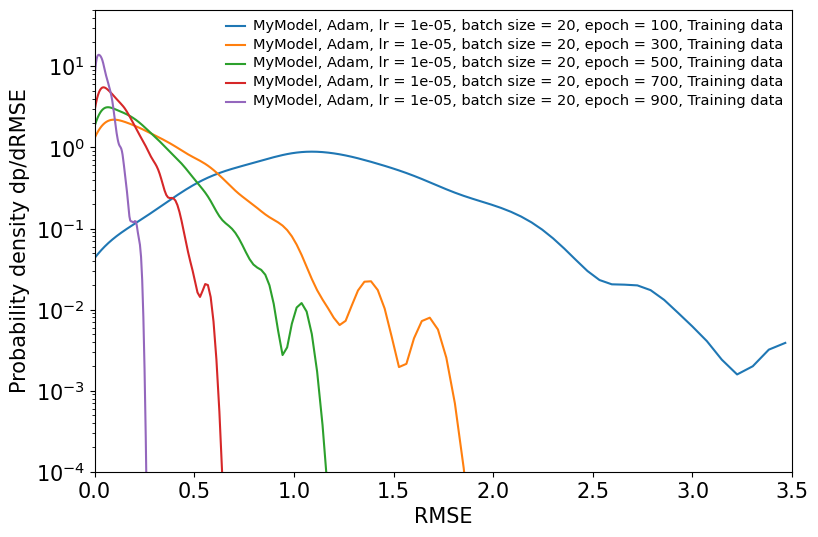

In [42]:
plot_diagnostics(train_diagnostics,xlog=False,ylog=True,dpdlog10=False,loss_name='RMSE',xlim=[0,3.5],ylim=[1E-4,50],epoch_skip=2,pdf_bin_n=500,pdf_log_grid=True)

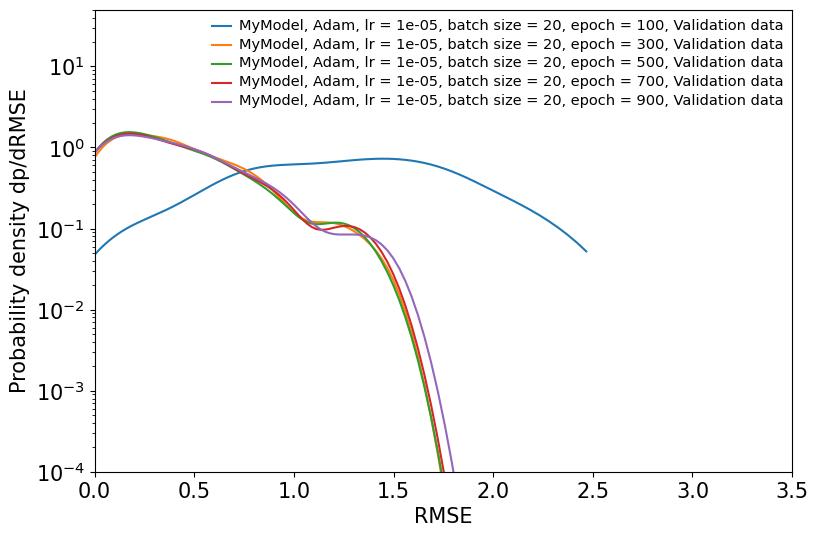

In [43]:
plot_diagnostics(valid_diagnostics,xlog=False,ylog=True,dpdlog10=False,loss_name='RMSE',xlim=[0,3.5],ylim=[1E-4,50],epoch_skip=2,pdf_bin_n=500,pdf_log_grid=True)